In [3]:
import cv2
import numpy as np
import os
import matplotlib.pyplot as plt

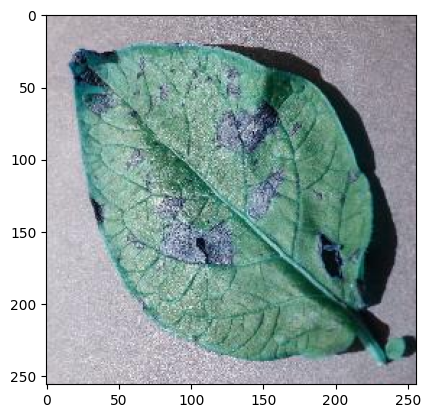

In [6]:
img=cv2.imread("PlantVillage/Potato___Early_blight/0a8a68ee-f587-4dea-beec-79d02e7d3fa4___RS_Early.B 8461.JPG")
plt.imshow(img)
# plt.axis("off")
plt.show()







(256, 256, 3)
(200, 200, 3)


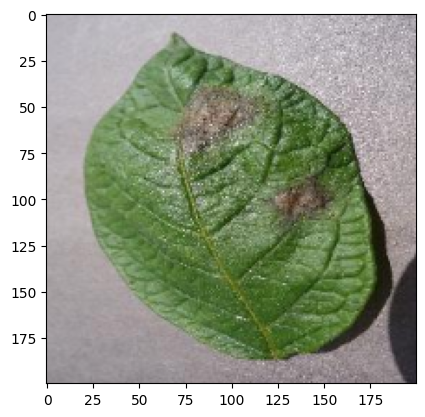

In [13]:
img=cv2.imread("PlantVillage/Potato___Late_blight/0acdc2b2-0dde-4073-8542-6fca275ab974___RS_LB 4857.JPG")

print(img.shape)
img=cv2.cvtColor(img,cv2.COLOR_BGR2RGB)
img=cv2.resize(img,(200,200))
print(img.shape)
plt.imshow(img)
# plt.axis("off")
plt.show()




In [18]:
import tensorflow as tf

In [19]:
from tensorflow.keras import layers, models

In [72]:
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
    layers.RandomContrast(0.1),
])

model = models.Sequential([
    layers.Rescaling(1./255,),

    data_augmentation,

    layers.Conv2D(64, (3,3), padding="same"),
    layers.BatchNormalization(),
    layers.ReLU(),
    layers.Conv2D(64, (3,3), padding="same"),
    layers.BatchNormalization(),
    layers.ReLU(),
    layers.MaxPooling2D(2,2),
    layers.Dropout(0.35),  

    layers.Conv2D(128, (3,3), padding="same"),
    layers.BatchNormalization(),
    layers.ReLU(),
    layers.Conv2D(128, (3,3), padding="same"),
    layers.BatchNormalization(),
    layers.ReLU(),
    layers.MaxPooling2D(2,2),
    layers.Dropout(0.35),

    layers.Conv2D(256, (3,3), padding="same"),
    layers.BatchNormalization(),
    layers.ReLU(),
    layers.Conv2D(256, (3,3), padding="same"),
    layers.BatchNormalization(),
    layers.ReLU(),
    layers.MaxPooling2D(2,2),
    layers.Dropout(0.35),

    layers.GlobalAveragePooling2D(),  
    layers.Dense(256, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.6),  
    layers.Dense(3, activation='softmax')
])

In [73]:
history=model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
    loss="sparse_categorical_crossentropy",
    metrics=['accuracy'],
    

)

model.summary()

Model: "sequential_15"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling_7 (Rescaling)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential_14 (Sequential)      │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_31 (Conv2D)              │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_38          │ ?                      │   0 (unbuilt) │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_31 (ReLU)                 │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_32 (Conv2D)              │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_39          │ ?                      │   0 (unbuilt) │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_32 (ReLU)                 │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_19 (MaxPooling2D) │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_13 (Dropout)            │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_33 (Conv2D)              │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_40          │ ?                      │   0 (unbuilt) │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_33 (ReLU)                 │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_34 (Conv2D)              │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_41          │ ?                      │   0 (unbuilt) │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_34 (ReLU)                 │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_20 (MaxPooling2D) │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_14 (Dropout)            │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_35 (Conv2D)              │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_42          │ ?                      │   0 (unbuilt) │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_35 (ReLU)                 │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_36 (Conv2D)              │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [74]:
main_directory="PlantVillage/"

In [75]:
train_ds = tf.keras.utils.image_dataset_from_directory(
    main_directory,
    labels="inferred",
    label_mode="int",
    batch_size=32,
    image_size=(200,200),
    shuffle=True,
    validation_split=0.2,  
    subset="training",
    seed=123
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    main_directory,
    labels="inferred",
    label_mode="int",
    batch_size=32,
    image_size=(200,200),
    shuffle=True,
    validation_split=0.2,
    subset="validation",
    seed=123
)


Found 2112 files belonging to 3 classes.
Using 1690 files for training.
Found 2112 files belonging to 3 classes.
Using 422 files for validation.


In [76]:
order_class=train_ds.class_names
order_class


['Potato___Early_blight', 'Potato___Late_blight', 'Potato___healthy']

In [78]:
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor='val_loss',    
    patience=10,            
    restore_best_weights=True  
)




In [ ]:

history=model.fit(train_ds, validation_data=val_ds, epochs=50,callbacks=[early_stop])
model.save("plant_disease_model_1.keras")


Epoch 1/50
53/53 ━━━━━━━━━━━━━━━━━━━━ 965s 18s/step - accuracy: 0.8538 - loss: 0.4148 - val_accuracy: 0.4479 - val_loss: 1.2082
Epoch 2/50
 1/53 ━━━━━━━━━━━━━━━━━━━━ 17:27 20s/step - accuracy: 1.0000 - loss: 0.1237

In [ ]:
test_labels=model.predict('')
test_labels


395/395 ━━━━━━━━━━━━━━━━━━━━ 15s 38ms/step


array([[9.2211690e-07, 9.4307197e-04, 4.6518251e-02, ..., 1.4664257e-04,
        4.5627687e-05, 5.9321602e-03],
       [2.0923022e-05, 1.6317464e-03, 1.3046024e-02, ..., 1.7171447e-05,
        9.1674017e-05, 2.1785824e-03],
       [1.1133409e-04, 4.1223196e-03, 1.9473372e-02, ..., 2.3019820e-04,
        4.8340694e-04, 6.3304015e-02],
       ...,
       [7.2806220e-06, 2.7038598e-02, 7.4854866e-04, ..., 9.7464428e-05,
        2.6331114e-04, 3.7103083e-03],
       [2.4064843e-06, 5.1774856e-02, 1.8512731e-03, ..., 2.8423284e-04,
        8.9240457e-05, 2.5183728e-02],
       [4.6760414e-07, 2.0064020e-03, 1.4841410e-04, ..., 1.9435805e-05,
        3.5192021e-05, 2.7016157e-03]], shape=(12630, 43), dtype=float32)

In [10]:
import tensorflow as tf

from tensorflow.keras.applications import ResNet50
from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import numpy as np
import matplotlib.pyplot as plt

In [11]:
data_set_path="PlantVillage"

Image_Size=(200,200)

Batch_Size=32

Epochs_1=50

Epochs_2=30

Class_Name=['Potato___Early_blight', 'Potato___healthy', 'Potato___Late_blight']

Num_Class=3





In [12]:
train_ds = tf.keras.utils.image_dataset_from_directory(
    data_set_path,

    labels="inferred",

    label_mode="categorical",


    batch_size=Batch_Size,

    image_size=Image_Size,

    shuffle=True,
    validation_split=0.2,

    subset="training",
    seed=123
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    data_set_path,
    labels="inferred",
    label_mode="categorical",
    batch_size=Batch_Size,
    image_size=Image_Size,
    shuffle=True,
    validation_split=0.2,
    subset="validation",
    seed=123
)

Found 2112 files belonging to 3 classes.
Using 1690 files for training.
Found 2112 files belonging to 3 classes.
Using 422 files for validation.


In [13]:
rescale= tf.keras.layers.Rescaling(1/255)

In [14]:
base_model= ResNet50(
    weights="imagenet",
    include_top=False,
    input_shape=(200,200,3)
    
)

base_model.trainable=False

model = models.Sequential([
    rescale,
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(Num_Class, activation='softmax')

    
    

    

    

    
    
    
])

In [15]:
model.compile(
    optimizer='adam',


    loss='categorical_crossentropy',


    metrics=['accuracy']
)



In [18]:
from tensorflow.keras.callbacks import EarlyStopping


early_stop = EarlyStopping(
    monitor='val_loss',    
    patience=10,            
    restore_best_weights=True  
)



history1 = model.fit(
    train_ds,

    epochs=Epochs_1,

    validation_data=val_ds,
    callbacks=[early_stop]
    
)


Epoch 1/50


53/53 ━━━━━━━━━━━━━━━━━━━━ 152s 3s/step - accuracy: 0.5609 - loss: 0.8988 - val_accuracy: 0.5664 - val_loss: 0.8185
Epoch 2/50
53/53 ━━━━━━━━━━━━━━━━━━━━ 129s 2s/step - accuracy: 0.6964 - loss: 0.7612 - val_accuracy: 0.7464 - val_loss: 0.7159
Epoch 3/50
53/53 ━━━━━━━━━━━━━━━━━━━━ 130s 2s/step - accuracy: 0.6911 - loss: 0.7491 - val_accuracy: 0.7867 - val_loss: 0.6532
Epoch 4/50
53/53 ━━━━━━━━━━━━━━━━━━━━ 129s 2s/step - accuracy: 0.7592 - loss: 0.6560 - val_accuracy: 0.7844 - val_loss: 0.6064
Epoch 5/50
53/53 ━━━━━━━━━━━━━━━━━━━━ 129s 2s/step - accuracy: 0.7822 - loss: 0.6064 - val_accuracy: 0.7867 - val_loss: 0.5852
Epoch 6/50
53/53 ━━━━━━━━━━━━━━━━━━━━ 130s 2s/step - accuracy: 0.7840 - loss: 0.5896 - val_accuracy: 0.7820 - val_loss: 0.5653
Epoch 7/50
53/53 ━━━━━━━━━━━━━━━━━━━━ 135s 3s/step - accuracy: 0.7947 - loss: 0.5754 - val_accuracy: 0.7986 - val_loss: 0.5400
Epoch 8/50
53/53 ━━━━━━━━━━━━━━━━━━━━ 135s 3s/step - accuracy: 0.7905 - loss: 0.5621 - val_accuracy: 0.7962 - val_loss: 0.

In [ ]:
base_model.trainable = True
# Unfreeze ResNet layers

for layer in base_model.layers[:-20]:
    layer.trainable = False


model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)


early_stop = EarlyStopping(
    monitor='val_loss',    
    patience=10,            
    restore_best_weights=True  
)

history2 = model.fit(
    train_ds,
    epochs=Epochs_2,
    validation_data=val_ds,
    callbacks=[early_stop]
    
)

Epoch 1/30
53/53 ━━━━━━━━━━━━━━━━━━━━ 177s 3s/step - accuracy: 0.7456 - loss: 7.9135 - val_accuracy: 0.5924 - val_loss: 1.0507
Epoch 2/30
53/53 ━━━━━━━━━━━━━━━━━━━━ 151s 3s/step - accuracy: 0.8586 - loss: 0.4480 - val_accuracy: 0.6280 - val_loss: 1.3067
Epoch 3/30
53/53 ━━━━━━━━━━━━━━━━━━━━ 150s 3s/step - accuracy: 0.8645 - loss: 0.3624 - val_accuracy: 0.4882 - val_loss: 3.0311
Epoch 4/30
53/53 ━━━━━━━━━━━━━━━━━━━━ 151s 3s/step - accuracy: 0.8929 - loss: 0.3060 - val_accuracy: 0.6517 - val_loss: 1.7373
Epoch 5/30
53/53 ━━━━━━━━━━━━━━━━━━━━ 150s 3s/step - accuracy: 0.9000 - loss: 0.2676 - val_accuracy: 0.8057 - val_loss: 0.8575
Epoch 6/30
53/53 ━━━━━━━━━━━━━━━━━━━━ 151s 3s/step - accuracy: 0.9012 - loss: 0.2647 - val_accuracy: 0.8365 - val_loss: 0.5336
Epoch 7/30
53/53 ━━━━━━━━━━━━━━━━━━━━ 151s 3s/step - accuracy: 0.9095 - loss: 0.2361 - val_accuracy: 0.8294 - val_loss: 0.5157
Epoch 8/30
53/53 ━━━━━━━━━━━━━━━━━━━━ 150s 3s/step - accuracy: 0.9089 - loss: 0.2230 - val_accuracy: 0.8246 - v

In [23]:
model.save("potato_model.h5")
print("Done")

Done


In [25]:
import keras
model.save('my_model.keras') 
keras.saving.save_model(model, 'myModel.keras')

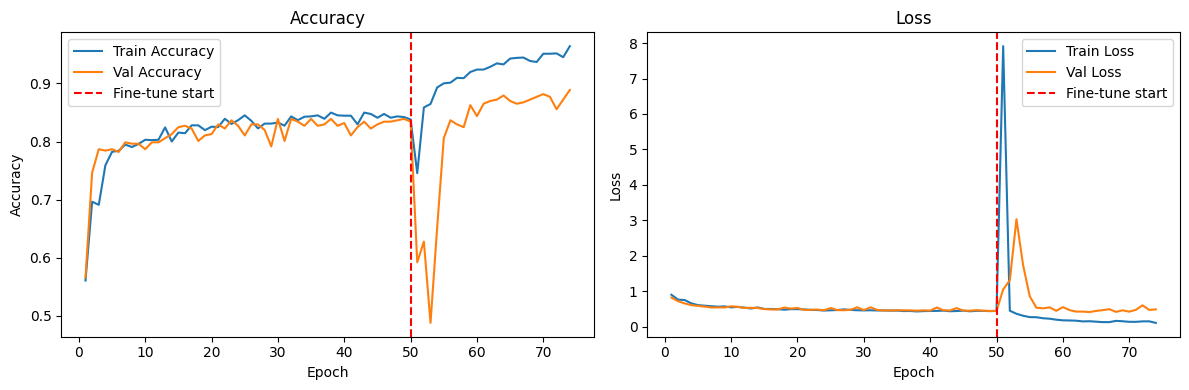

In [ ]:
acc      = history1.history['accuracy']     + history2.history['accuracy']
val_acc  = history1.history['val_accuracy'] + history2.history['val_accuracy']
loss     = history1.history['loss']         + history2.history['loss']
val_loss = history1.history['val_loss']     + history2.history['val_loss']
epochs   = range(1, len(acc) + 1)

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(epochs, acc,     label='Train Accuracy')
plt.plot(epochs, val_acc, label='Val Accuracy')
plt.axvline(x=50, color='red', linestyle='--', label='Fine-tune start')
plt.title('Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(epochs, loss,     label='Train Loss')
plt.plot(epochs, val_loss, label='Val Loss')
plt.axvline(x=50, color='red', linestyle='--', label='Fine-tune start')
plt.title('Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()

In [11]:
import tensorflow as tf
import numpy as np

model = tf.keras.models.load_model('potato_model.h5')


CLASS_NAMES = ['Potato_Early___blight', 'Potato___healthy', 'Potato___Late_blight']
IMAGE_SIZE  = (200, 200)


def predict_image(img_path):
    img = tf.keras.utils.load_img(img_path, target_size=IMAGE_SIZE)

    img_array = tf.keras.utils.img_to_array(img)

    img_array = tf.expand_dims(img_array, axis=0)

    predictions = model.predict(img_array)

    predicted_index = np.argmax(predictions[0])

    predicted_class = CLASS_NAMES[predicted_index]

    confidence = predictions[0][predicted_index] * 100

    print(f"Prediction : {predicted_class}")
    print(f"Confidence : {confidence:.2f}%")


predict_image('TEST/late/0e068694-63b7-4edf-a93d-f2e9f28efaa6___RS_LB 3923.JPG')


1/1 ━━━━━━━━━━━━━━━━━━━━ 9s 9s/step
Prediction : Potato___healthy
Confidence : 76.82%
